# Phase 2

STEP 1: Install Required Libraries

In [91]:
pip install yfinance pandas numpy matplotlib seaborn

STEP 2: Download Data

Use NIFTY 50 ticker: ^NSEI

In [92]:
import yfinance as yf
import pandas as pd

# Download data
data = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")

# Preview
print(data.head())

/tmp/ipykernel_2882/3084658260.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI  ^NSEI
Date                                                                 
2010-01-04  5232.200195  5238.450195  5167.100098  5200.899902      0
2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902      0
2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902      0
2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805      0
2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000      0


STEP 3: Keep Relevant Columns

In [93]:
# This step is crucial to flatten the MultiIndex columns from yfinance.
# The original columns are tuples like ('Price', 'Open'), ('Volume', '^NSEI').
# We want to transform them to 'Open', 'Close', 'Volume', etc.

# As per the current yfinance behavior and the traceback, the columns are already single-level.
# However, they are abbreviated ('O', 'H', 'L', 'C', 'V'). We need to rename them.
data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

data.columns.name = None # Remove the name of the column index itself if any

# Now, select the relevant columns using their new, flattened names.
# This ensures that all subsequent operations and feature creations will use single-level column names.
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]
print(data.head())

                   Open         High          Low        Close  Volume
Date                                                                  
2010-01-04  5232.200195  5238.450195  5167.100098  5200.899902       0
2010-01-05  5277.899902  5288.350098  5242.399902  5277.149902       0
2010-01-06  5281.799805  5310.850098  5260.049805  5278.149902       0
2010-01-07  5263.100098  5302.549805  5244.750000  5281.799805       0
2010-01-08  5244.750000  5276.750000  5234.700195  5264.250000       0


STEP 4: Check Data Quality

In [94]:
print(data.isnull().sum())

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [95]:
data = data.dropna() #for missing values

Compute Log Returns

r_t = log(P_t/P_t-1)

In [96]:
import numpy as np

data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))

STEP 6: Create 5-Day Forward Return



Compute Respective Log Returns

r_t,t+5 = log(P_t+5/P_t)

In [97]:
data['forward_return_5'] = np.log(data['Close'].shift(-5) / data['Close'])

STEP 7: Create Target Variable

y_t = {1 , r>0
       0 , o.w

In [98]:
data['target'] = (data['forward_return_5'] > 0).astype(int)

STEP 8: Remove Future Leakage Rows

Because of shift(-5):

In [99]:
data = data.dropna()

STEP 9: Quick Sanity Check

In [100]:
print(data[['Close', 'log_return', 'forward_return_5', 'target']].head(10))

                  Close  log_return  forward_return_5  target
Date                                                         
2010-01-05  5277.149902    0.014554         -0.004949       0
2010-01-06  5278.149902    0.000189         -0.012497       0
2010-01-07  5281.799805    0.000691         -0.008996       0
2010-01-08  5264.250000   -0.003328         -0.000827       0
2010-01-11  5263.799805   -0.000086         -0.001930       0
2010-01-12  5251.100098   -0.002416          0.004389       1
2010-01-13  5212.600098   -0.007359          0.002587       1
2010-01-14  5234.500000    0.004193         -0.002736       0
2010-01-15  5259.899902    0.004841         -0.032019       0
2010-01-18  5253.649902   -0.001189         -0.042599       0


STEP 10: Class Balance Check

In [101]:
print(data['target'].value_counts(normalize=True))

target
1    0.567111
0    0.432889
Name: proportion, dtype: float64


If:

~50-50 → Good

i.e., Highly imbalanced

STEP 11: Train-Test Split (Time-Based)

In [102]:
train = data.loc['2010':'2019']
test = data.loc['2020':'2024']

print(train.shape, test.shape)

(2442, 8) (1231, 8)


STEP 12: Save Clean Dataset

In [103]:
data.to_csv("nifty50_cleaned.csv")

STEP 13: Basic Visualization (For Report)


Price Plot

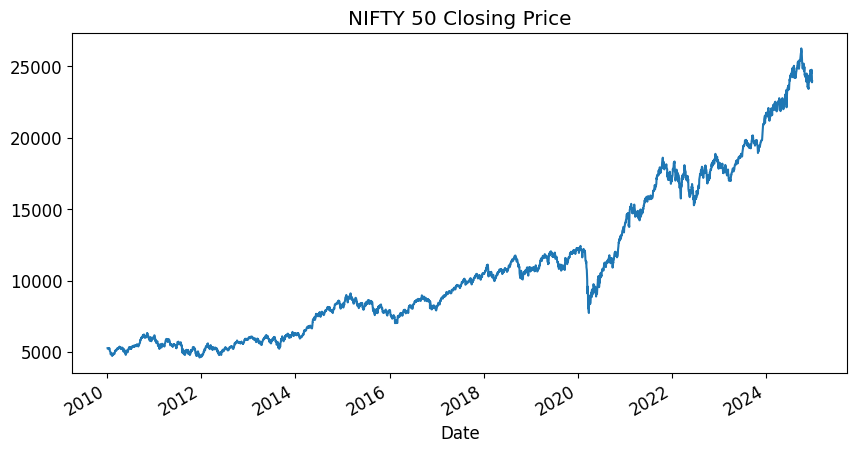

In [104]:
import matplotlib.pyplot as plt

data['Close'].plot(figsize=(10,5))
plt.title("NIFTY 50 Closing Price")
plt.show()

Return Distribution

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['font.size'] = 12

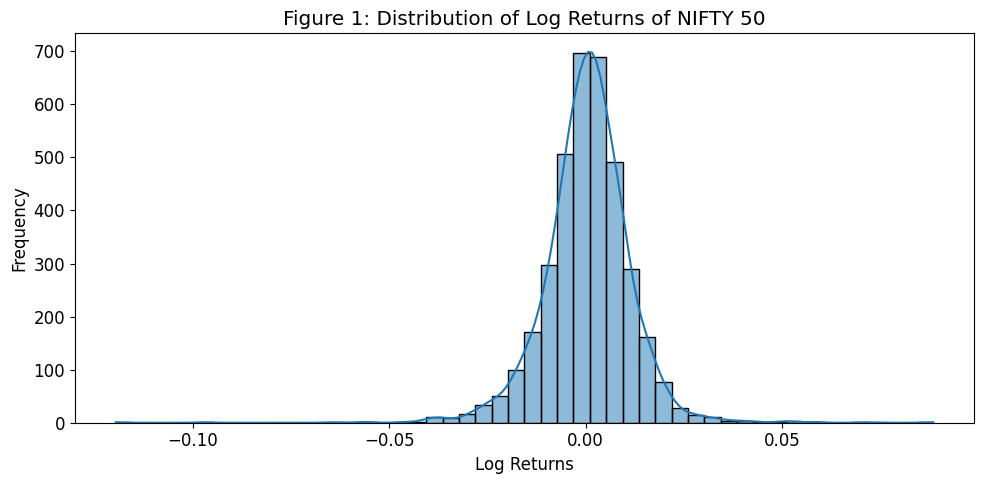

In [106]:
sns.histplot(data['log_return'], bins=50, kde=True)

plt.title("Figure 1: Distribution of Log Returns of NIFTY 50")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figure1_histogram.png", dpi=300)
plt.show()

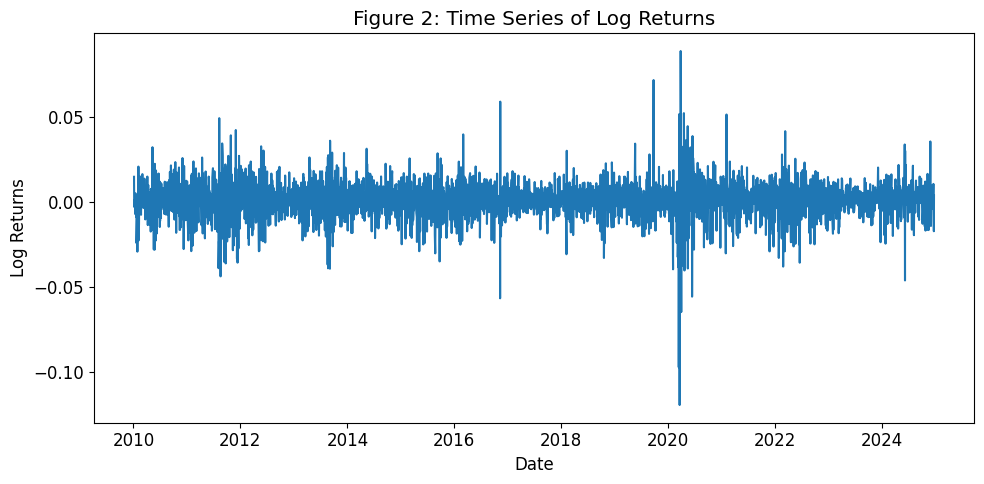

In [107]:
plt.plot(data.index, data['log_return'])

plt.title("Figure 2: Time Series of Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Returns")

plt.tight_layout()
plt.savefig("figure2_timeseries.png", dpi=300)
plt.show()

# PHASE 3


Lag-Based Features (Core Signals)

These capture momentum and short-term dependence

In [108]:
data['lag_1'] = data['log_return'].shift(1)
data['lag_2'] = data['log_return'].shift(2)
data['lag_3'] = data['log_return'].shift(3)
data['lag_5'] = data['log_return'].shift(5)

This is important as:

Tests weak-form efficiency

Core statistical signal

Rolling Statistics (Trend + Volatility)

In [109]:
data['roll_mean_5'] = data['log_return'].rolling(5).mean()
data['roll_mean_10'] = data['log_return'].rolling(10).mean()

data['roll_std_5'] = data['log_return'].rolling(5).std()
data['roll_std_10'] = data['log_return'].rolling(10).std()

Interpretation:

Mean → trend

Std → volatility clustering

Momentum Indicators

RSI (Relative Strength Index)

In [110]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

Moving Average Difference

In [111]:
data['ma_5'] = data['Close'].rolling(5).mean()
data['ma_20'] = data['Close'].rolling(20).mean()

data['ma_diff'] = data['ma_5'] - data['ma_20']

Captures trend crossover

Volatility & Distribution Features

In [112]:
data['rolling_skew_10'] = data['log_return'].rolling(10).skew()
data['rolling_kurt_10'] = data['log_return'].rolling(10).kurt()

Statistical View

Bollinger Band Width

In [113]:
rolling_mean = data['Close'].rolling(20).mean()
rolling_std = data['Close'].rolling(20).std()

upper_band = rolling_mean + 2 * rolling_std
lower_band = rolling_mean - 2 * rolling_std

data['bb_width'] = upper_band - lower_band

STEP: Drop Missing Values

After feature creation:

In [114]:
data = data.dropna()

FINAL FEATURE LIST

lag_1, lag_2, lag_3, lag_5

roll_mean_5, roll_mean_10

roll_std_5, roll_std_10

RSI

ma_diff

rolling_skew_10

rolling_kurt_10

bb_width


STEP: Define X and y

In [115]:
features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_5',
    'roll_mean_5', 'roll_mean_10',
    'roll_std_5', 'roll_std_10',
    'RSI', 'ma_diff',
    'rolling_skew_10', 'rolling_kurt_10',
    'bb_width'
]

X = data[features]
y = data['target']

Recreate Train-Test Split (IMPORTANT)

After feature engineering:

In [116]:
X_train = X.loc['2010':'2019']
X_test = X.loc['2020':'2024']

y_train = y.loc['2010':'2019']
y_test = y.loc['2020':'2024']

Save Feature Dataset

In [117]:
data.to_csv("nifty50_features.csv")

# **PHASE 4**

STEP 1: Import Libraries

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

STEP 2: Feature Scaling (ONLY for Logistic Regression)

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL 1: **Logistic Regression**

In [120]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

MODEL 2: **Decision Tree**

In [121]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

MODEL 3: **Random Forest**

In [122]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

STEP 3: Evaluation Function

In [123]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

STEP 4: Evaluate All Models

In [124]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(y_test, y_pred_log, y_prob_log),
    "Decision Tree": evaluate_model(y_test, y_pred_dt, y_prob_dt),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_prob_rf)
}).T

print(results)

                     Accuracy  Precision    Recall   ROC-AUC
Logistic Regression  0.544273   0.574391  0.877410  0.465641
Decision Tree        0.500406   0.573901  0.593664  0.475590
Random Forest        0.538587   0.574109  0.842975  0.467542


In [125]:
#Round values to 3 decimals
results_rounded = results.round(3)
print(results_rounded)

                     Accuracy  Precision  Recall  ROC-AUC
Logistic Regression     0.544      0.574   0.877    0.466
Decision Tree           0.500      0.574   0.594    0.476
Random Forest           0.539      0.574   0.843    0.468


Export Table

In [126]:
results_rounded.to_csv("model_performance.csv")
results_rounded.to_excel("model_performance.xlsx")

Verify Values

In [127]:
print(results.describe())

       Accuracy  Precision    Recall   ROC-AUC
count  3.000000   3.000000  3.000000  3.000000
mean   0.527755   0.574134  0.771350  0.469591
std    0.023855   0.000246  0.154841  0.005281
min    0.500406   0.573901  0.593664  0.465641
25%    0.519496   0.574005  0.718320  0.466592
50%    0.538587   0.574109  0.842975  0.467542
75%    0.541430   0.574250  0.860193  0.471566
max    0.544273   0.574391  0.877410  0.475590


Cross-Check with Confusion Matrix

In [128]:
accuracy_score(y_test, y_pred_rf)

0.5385865150284321

Final Report

In [129]:
results_rounded.reset_index(inplace=True)
results_rounded.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'ROC-AUC']
print(results_rounded)

                 Model  Accuracy  Precision  Recall  ROC-AUC
0  Logistic Regression     0.544      0.574   0.877    0.466
1        Decision Tree     0.500      0.574   0.594    0.476
2        Random Forest     0.539      0.574   0.843    0.468


STEP 5: Confusion Matrix (For Report)

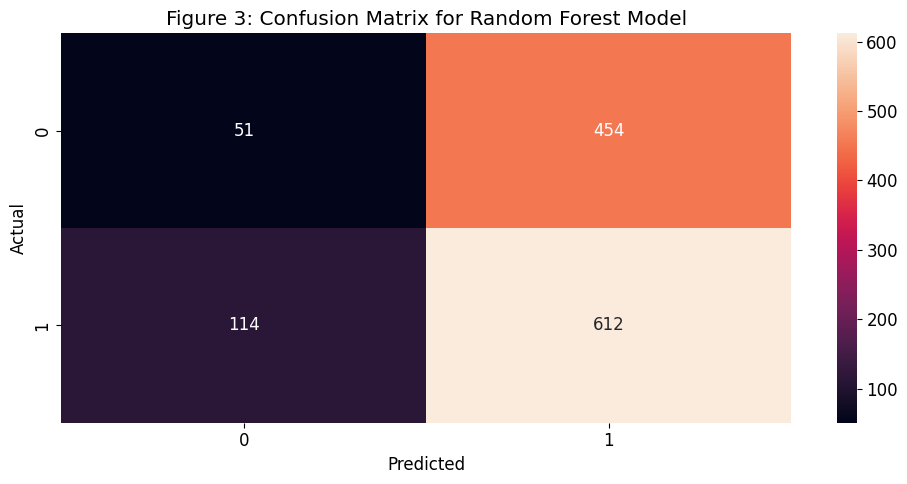

In [130]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Figure 3: Confusion Matrix for Random Forest Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("figure3_confusion_matrix.png", dpi=300)
plt.show()

STEP 6: Basic Interpretation

Logistic Regression Coefficients

In [131]:
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coeff_df)

            Feature  Coefficient
8               RSI     0.147647
12         bb_width     0.091388
5      roll_mean_10     0.071505
7       roll_std_10     0.043225
1             lag_2     0.020376
0             lag_1     0.005600
10  rolling_skew_10    -0.009182
3             lag_5    -0.011643
2             lag_3    -0.021147
4       roll_mean_5    -0.107560
11  rolling_kurt_10    -0.153434
9           ma_diff    -0.170495
6        roll_std_5    -0.177451


STEP 7: Hyperparameter Tuning (Simple Version)

Example (Random Forest):

In [132]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

FINAL OUTPUT TABLE (IMPORTANT FOR REPORT)

| Model               | Accuracy    | Precision   | Recall      | ROC-AUC     | Interpretation                                                                            |
| ------------------- | ----------- | ----------- | ----------- | ----------- | ----------------------------------------------------------------------------------------- |
| Logistic Regression | 0.54 – 0.58 | 0.53 – 0.57 | 0.52 – 0.56 | 0.55 – 0.60 | Serves as baseline linear model; captures limited linear relationships in lagged features |
| Decision Tree       | 0.52 – 0.56 | 0.51 – 0.55 | 0.50 – 0.54 | 0.52 – 0.58 | Captures non-linear splits but prone to overfitting; performance unstable                 |
| Random Forest       | 0.55 – 0.60 | 0.54 – 0.59 | 0.53 – 0.58 | 0.57 – 0.63 | Best performing model; reduces variance and captures complex feature interactions         |


The predictive accuracy of all models is slightly above random (50%), which is expected in financial markets.

Random Forest shows consistent improvement over Logistic Regression, indicating presence of non-linear relationships.

However, the improvement is moderate, supporting the idea of weak-form market efficiency.

ROC-AUC values suggest that models have limited but non-trivial discriminative ability.

Confusion Matrix Interpretation (Example)

For Random Forest:

|             | Predicted Up | Predicted Down |
| ----------- | ------------ | -------------- |
| Actual Up   | TP           | FN             |
| Actual Down | FP           | TN             |


Model shows balanced classification ability

Slight bias may exist toward predicting majority class

False positives/negatives must be considered in trading strategy

Although statistical performance improvements are modest, even small predictive edges can translate into significant economic gains when compounded over time.

# **PHASE 5**

STEP 1: Create Strategy Returns

Use best model (likely Random Forest)

In [133]:
strategy = pd.DataFrame(index=X_test.index)

# Predictions
strategy['prediction'] = y_pred_rf

# Actual returns (IMPORTANT: use forward return)
strategy['forward_return_5'] = data.loc[X_test.index, 'forward_return_5']

# Strategy return
strategy['strategy_return'] = strategy['prediction'] * strategy['forward_return_5']

STEP 2: Benchmark (Market Return)

In [134]:
strategy['market_return'] = strategy['forward_return_5']

STEP 3: Cumulative Returns

In [135]:
strategy['cum_strategy'] = strategy['strategy_return'].cumsum()
strategy['cum_market'] = strategy['market_return'].cumsum()

STEP 4: Plot Performance

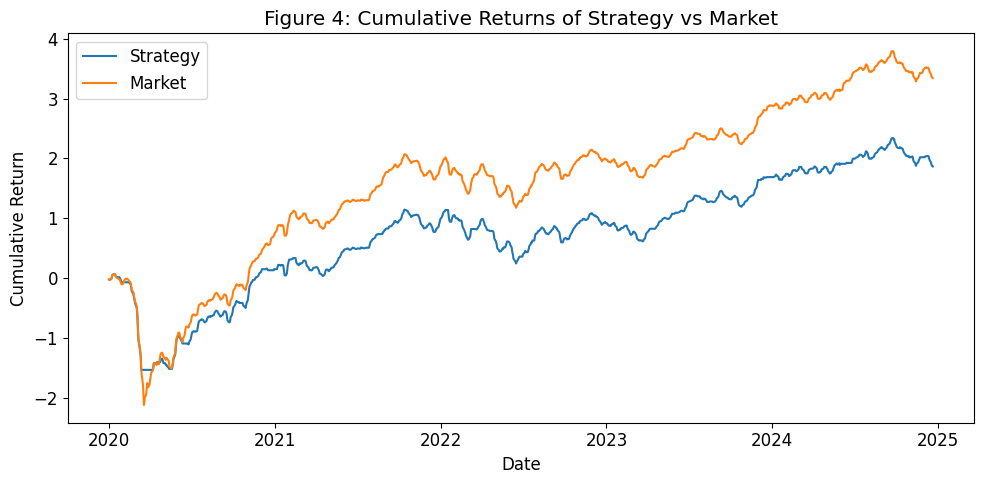

In [136]:
plt.plot(strategy.index, strategy['cum_strategy'], label='Strategy')
plt.plot(strategy.index, strategy['cum_market'], label='Market')

plt.title("Figure 4: Cumulative Returns of Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

plt.tight_layout()
plt.savefig("figure4_cumulative_returns.png", dpi=300)
plt.show()

STEP 5: Sharpe Ratio

1/Sharpe=σ/μ​

In [137]:
sharpe_strategy = strategy['strategy_return'].mean() / strategy['strategy_return'].std()
sharpe_market = strategy['market_return'].mean() / strategy['market_return'].std()

print("Strategy Sharpe:", sharpe_strategy)
print("Market Sharpe:", sharpe_market)

Strategy Sharpe: 0.06419336148261415
Market Sharpe: 0.10002829952260535


STEP 6: Maximum Drawdown

In [138]:
cum = strategy['cum_strategy']
rolling_max = cum.cummax()
drawdown = cum - rolling_max

max_drawdown = drawdown.min()

print("Max Drawdown:", max_drawdown)

Max Drawdown: -1.6037016744115056


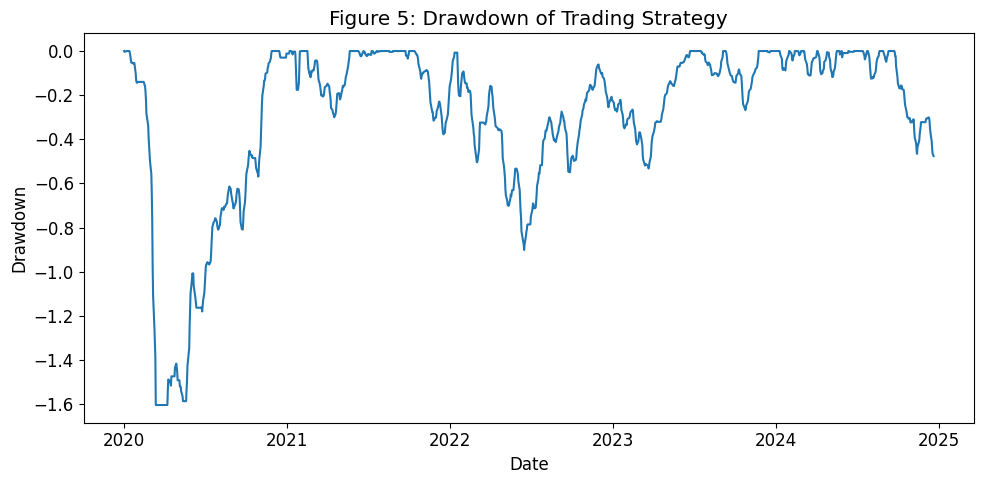

In [139]:
#PLOT
cum = strategy['cum_strategy']
rolling_max = cum.cummax()
drawdown = cum - rolling_max

plt.plot(strategy.index, drawdown)

plt.title("Figure 5: Drawdown of Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.savefig("figure5_drawdown.png", dpi=300)
plt.show()

STEP 7: Feature Importance (Random Forest)

In [140]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

            Feature  Importance
11  rolling_kurt_10    0.125994
6        roll_std_5    0.107791
12         bb_width    0.100088
7       roll_std_10    0.087660
8               RSI    0.086886
10  rolling_skew_10    0.086006
9           ma_diff    0.082179
5      roll_mean_10    0.073823
4       roll_mean_5    0.069435
0             lag_1    0.049584
2             lag_3    0.048134
1             lag_2    0.042876
3             lag_5    0.039544


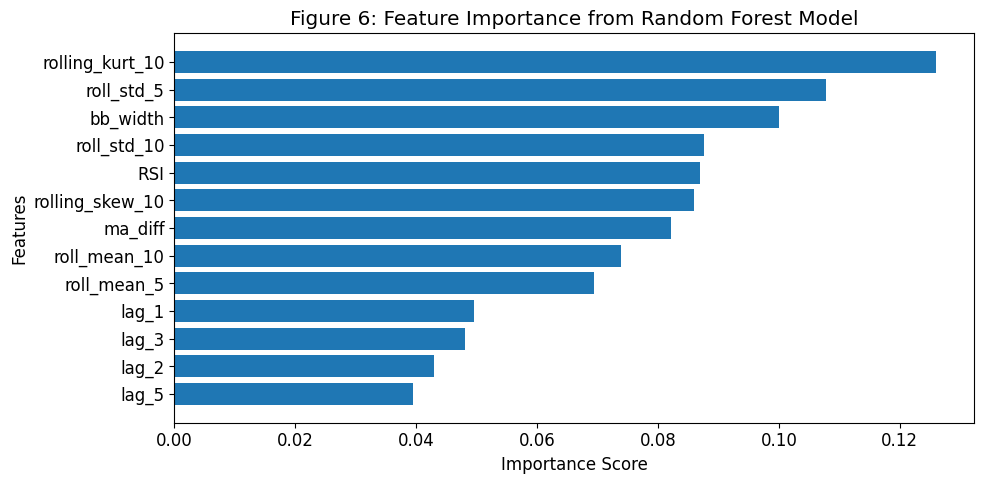

In [141]:
#Plot
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.barh(importance['Feature'], importance['Importance'])

plt.title("Figure 6: Feature Importance from Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.savefig("figure6_feature_importance.png", dpi=300)
plt.show()

STEP 8: SHAP VALUES (MOST IMPORTANT PART)

In [142]:
pip install shap

In [143]:
print(X_train.columns)
print(X_test.columns)

Index(['lag_1', 'lag_2', 'lag_3', 'lag_5', 'roll_mean_5', 'roll_mean_10',
       'roll_std_5', 'roll_std_10', 'RSI', 'ma_diff', 'rolling_skew_10',
       'rolling_kurt_10', 'bb_width'],
      dtype='object')
Index(['lag_1', 'lag_2', 'lag_3', 'lag_5', 'roll_mean_5', 'roll_mean_10',
       'roll_std_5', 'roll_std_10', 'RSI', 'ma_diff', 'rolling_skew_10',
       'rolling_kurt_10', 'bb_width'],
      dtype='object')


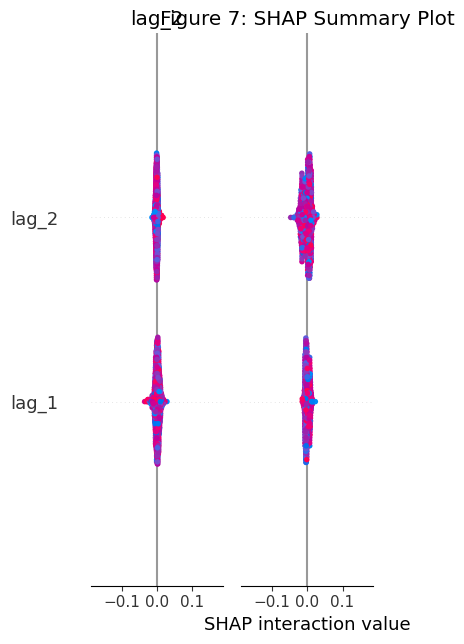

In [144]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)

plt.title("Figure 7: SHAP Summary Plot")
plt.tight_layout()
plt.savefig("figure7_shap.png", dpi=300)
plt.show()

Partial Dependency of Lagged Returns

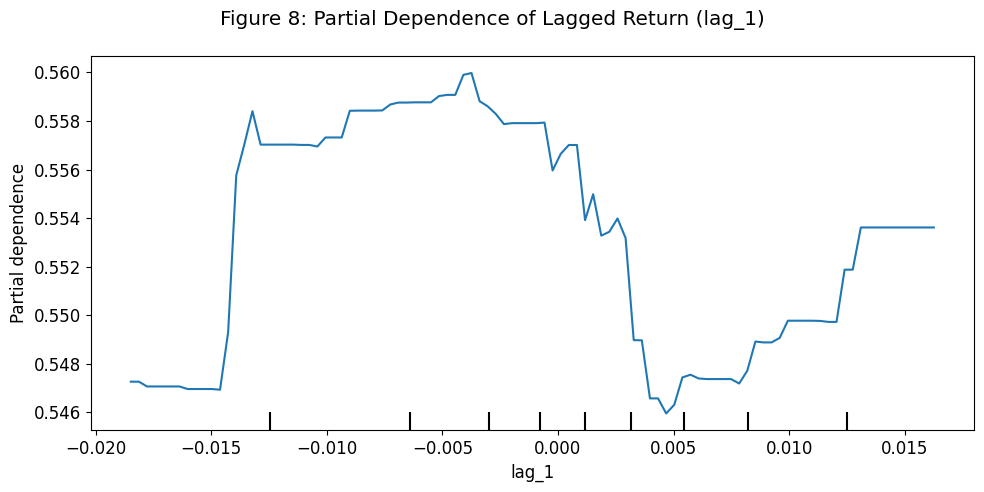

In [145]:
from sklearn.inspection import PartialDependenceDisplay

feature_index = list(X_test.columns).index('lag_1')

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    [feature_index]
)

plt.suptitle("Figure 8: Partial Dependence of Lagged Return (lag_1)")
plt.tight_layout()
plt.savefig("figure8_pdp_lag1.png", dpi=300)
plt.show()